### Linear Interpolation

**Linear Interpolation** estimates the value of a function at an intermediate point by assuming the function behaves linearly between two known data points \\((x_0, y_0)\\) and \\((x_1, y_1)\\):
$$
y = y_0 + (x - x_0)\,\frac{y_1 - y_0}{x_1 - x_0}
$$

This is the simplest interpolation technique. It is exact for linear functions, but introduces error for curved (nonlinear) data, especially when the spacing between known points is large.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return np.sin(x)

# Known data points sampled from f
x_data = np.linspace(0, np.pi, 6)
y_data = f(x_data)


In [3]:
def linear_interpolate_table(x_data, y_data, x_query):
    print(f"{'i':>2} {'x0':>10} {'x1':>10} {'y0':>10} {'y1':>10} {'y_interp':>12}")
    print("-" * 60)

    for i in range(len(x_data) - 1):
        x0, x1 = x_data[i], x_data[i + 1]
        if x0 <= x_query <= x1:
            y0, y1 = y_data[i], y_data[i + 1]
            y_interp = y0 + (x_query - x0) * (y1 - y0) / (x1 - x0)
            print(f"{i:2d} {x0:10.6f} {x1:10.6f} {y0:10.6f} {y1:10.6f} {y_interp:12.6f}")
            return y_interp

    raise ValueError("x_query outside the range of x_data")


In [4]:
x_query = 1.0
y_interp = linear_interpolate_table(x_data, y_data, x_query)
print(f"\nInterpolated value at x={x_query}: {y_interp:.6f}")
print(f"True value f({x_query}) = {f(x_query):.6f}")


 i         x0         x1         y0         y1     y_interp
------------------------------------------------------------
 1   0.628319   1.256637   0.587785   0.951057     0.802678

Interpolated value at x=1.0: 0.802678
True value f(1.0) = 0.841471


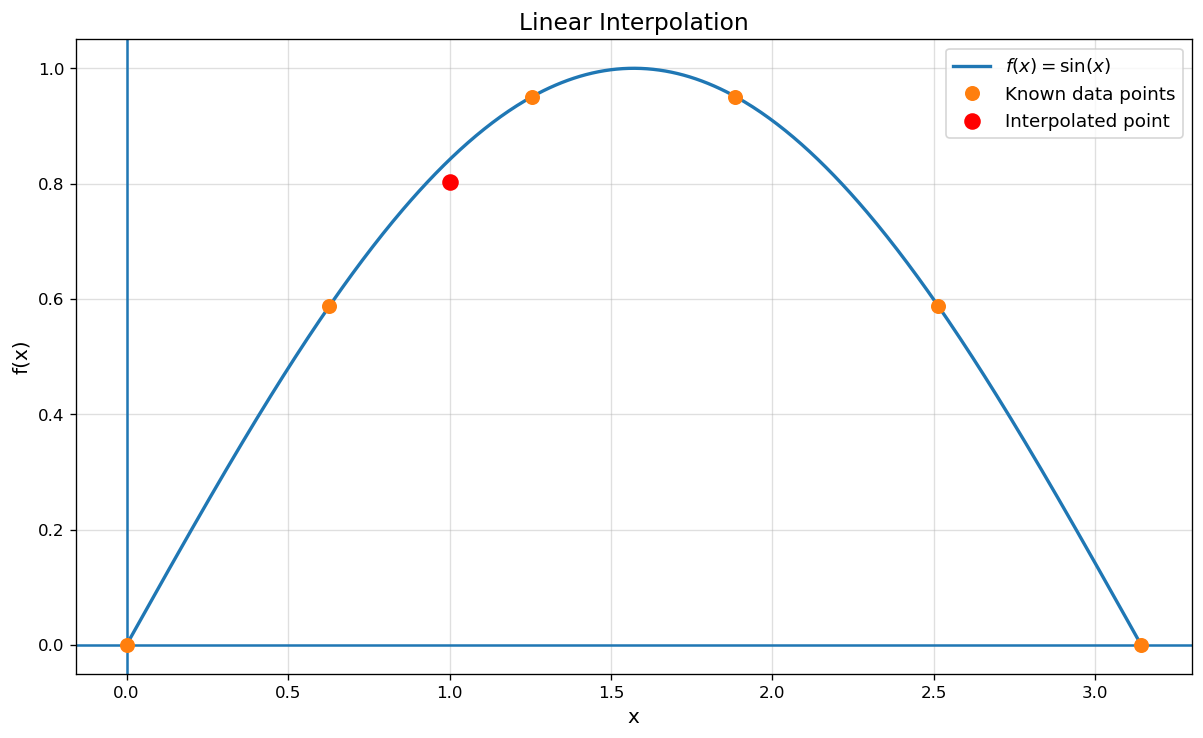

In [5]:
plt.figure(figsize=(12, 7), dpi=120)

# Axes lines (Desmos-style)
plt.axhline(0)
plt.axvline(0)

x = np.linspace(0, np.pi, 500)
y = f(x)

plt.plot(x, y, linewidth=2, label=r"$f(x)=\sin(x)$")
plt.plot(x_data, y_data, 'o', markersize=8, label="Known data points")
plt.scatter([x_query], [y_interp], s=80, zorder=5, color="red", label="Interpolated point")

plt.grid(True, alpha=0.4)
plt.xlabel("x", fontsize=12)
plt.ylabel("f(x)", fontsize=12)
plt.title("Linear Interpolation", fontsize=14)

plt.legend(fontsize=11)
plt.show()
